Name: Sakher shabil
PRN:25070126150
Brach: AIML C3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/adult.csv.zip')
print('shape',df.shape)
df.head()

shape (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
df.duplicated().sum()

np.int64(52)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, ":", len(outliers), "outliers")

for col in ["age","fnlwgt","educational-num","capital-gain","capital-loss","hours-per-week"]:
    detect_outliers(col)

age : 215 outliers
fnlwgt : 1453 outliers
educational-num : 1787 outliers
capital-gain : 4035 outliers
capital-loss : 2282 outliers
hours-per-week : 13486 outliers


In [ ]:
def outlier_bounds(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5*IQR, Q3 + 1.5*IQR

In [ ]:
df["capital-gain"] = np.log1p(df["capital-gain"])
df["capital-loss"] = np.log1p(df["capital-loss"])

In [ ]:
df.drop("fnlwgt", axis=1, inplace=True)

In [ ]:
lower, upper = outlier_bounds("age")
print(lower, upper)

-2.0 78.0


In [ ]:
df["age"] = np.clip(df["age"], lower, upper)

In [ ]:
# FIRST
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

# THEN encoding

In [ ]:
df["hours-per-week"]

,hours-per-week
0,40
1,50
2,40
3,40
5,30
...,...
48837,38
48838,40
48839,40
48840,20


In [ ]:
df.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0.000000,0.0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.000000,0.0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0.000000,0.0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,8.947546,0.0,40,United-States,>50K
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0.000000,0.0,30,United-States,<=50K


In [ ]:
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})

In [ ]:
df = pd.get_dummies(df, columns=[
    "workclass", "education", "marital-status",
    "occupation", "relationship", "race",
    "gender", "native-country"
])

In [ ]:
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    "age", "educational-num",
    "capital-gain", "capital-loss", "hours-per-week"
]

df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
df.columns

Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'income', 'workclass_Federal-gov',
       'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc',
       ...
       'native-country_Portugal', 'native-country_Puerto-Rico',
       'native-country_Scotland', 'native-country_South',
       'native-country_Taiwan', 'native-country_Thailand',
       'native-country_Trinadad&Tobago', 'native-country_United-States',
       'native-country_Vietnam', 'native-country_Yugoslavia'],
      dtype='object', length=104)

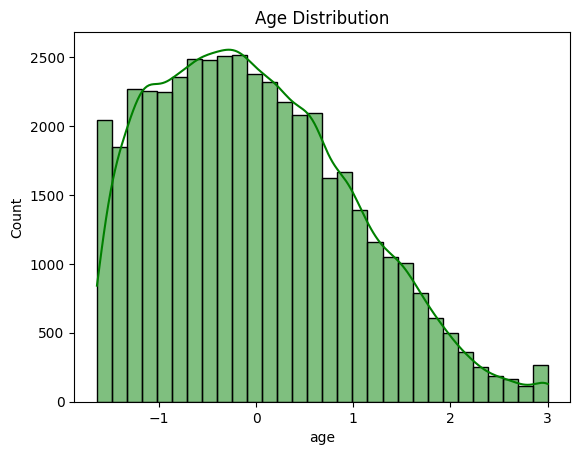

In [ ]:
sns.histplot(df['age'], bins=30,color='green', kde=True)
plt.title("Age Distribution")
plt.show()

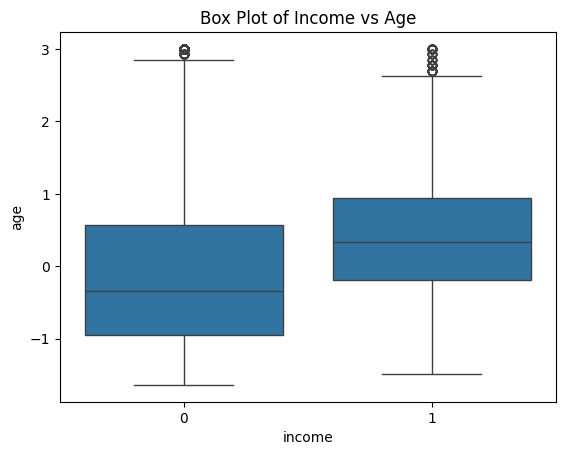

In [ ]:
sns.boxplot(x='income', y='age', data=df)
plt.title('Box Plot of Income vs Age')
plt.show()

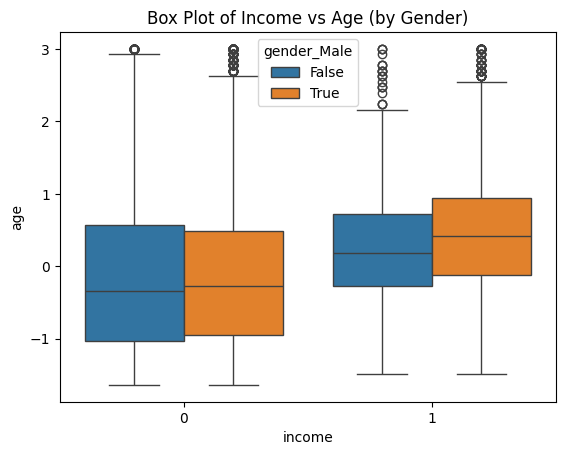

In [ ]:
sns.boxplot(x='income', y='age', hue='gender_Male', data=df)
plt.title('Box Plot of Income vs Age (by Gender)')
plt.show()

<Axes: xlabel='income', ylabel='age'>

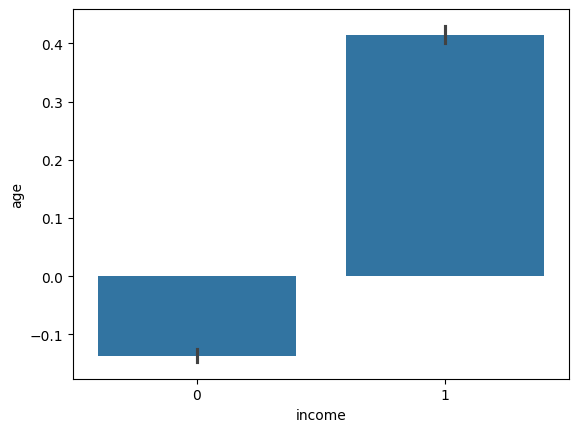

In [ ]:
sns.barplot(x='income', y='age', data=df)

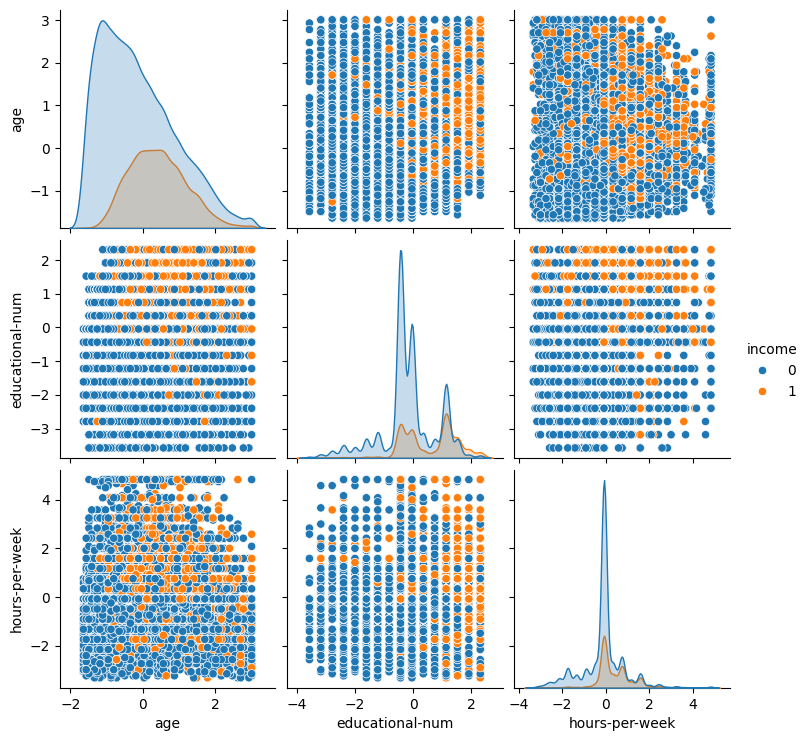

In [ ]:
sns.pairplot(df, vars=[
    'age', 'educational-num', 'hours-per-week'
], hue='income')
plt.show()

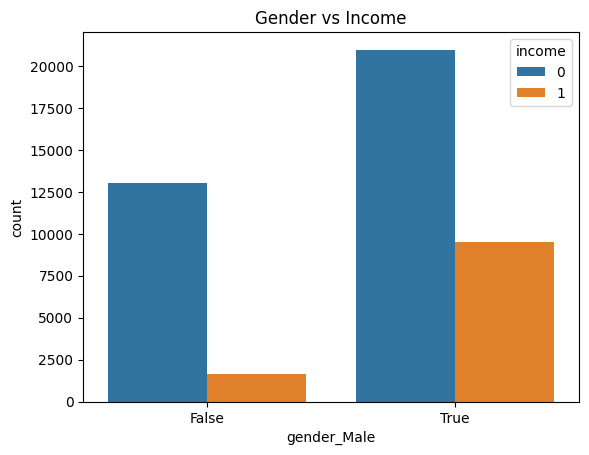

In [ ]:
sns.countplot(x='gender_Male', hue='income', data=df)
plt.title("Gender vs Income")
plt.show()

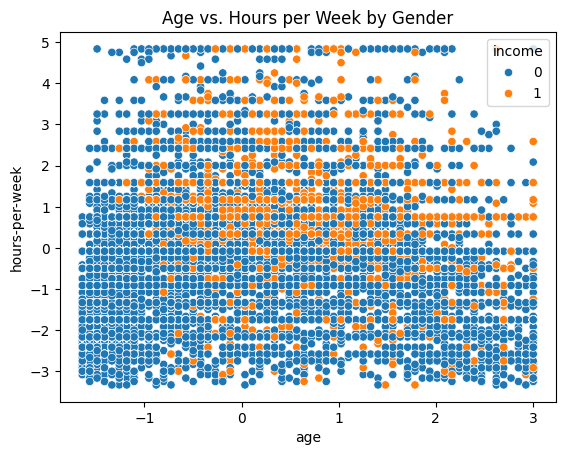

In [ ]:
sns.scatterplot(x='age', y='hours-per-week', hue='income', data=df)
plt.title('Age vs. Hours per Week by Gender')
plt.show()

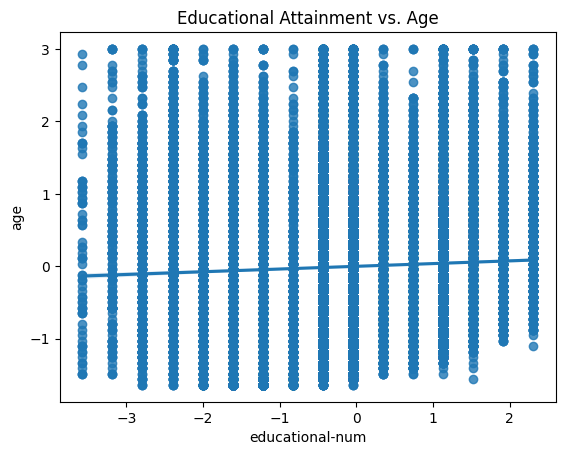

In [ ]:
sns.regplot(x='educational-num', y='age', data=df)
plt.title('Educational Attainment vs. Age')
plt.show()

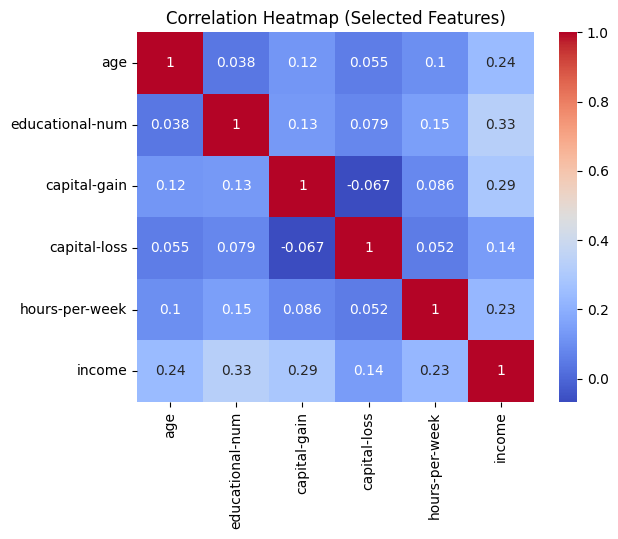

In [ ]:
cols = [
    'age',
    'educational-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'income'
]

corr_matrix = df[cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Selected Features)")
plt.show()

In [ ]:
corr = df.corr(numeric_only=True)['income'].sort_values(ascending=False)

print(corr)

income                               1.000000
marital-status_Married-civ-spouse    0.446013
relationship_Husband                 0.403505
educational-num                      0.332981
capital-gain                         0.287767
                                       ...   
occupation_Other-service            -0.165518
relationship_Not-in-family          -0.195294
gender_Female                       -0.215741
relationship_Own-child              -0.222633
marital-status_Never-married        -0.319262
Name: income, Length: 104, dtype: float64
